In [1]:
##imports
from Rotor import Rotor
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, List, Literal
from pathlib import Path

from globals import main_dir,data_dir, plot_dir, res_dir
import plotting_routines

import pandas as pd



In [2]:
J = [1.6, 2, 2.4]
TC_l = []
PC_l = []
R = 0.7
dfs = []

In [3]:

for i, j in enumerate(J):
    Vinf = np.array([60,0,0])
    n = Vinf[0]/(j*2*R)
    Ome  = n*2*np.pi
    Vinf_wing = np.array([1,0,0])
    c_R_func:Callable = lambda r_R : 0.18-0.06*r_R
    twst_func:Callable = lambda r_R : -50*r_R+35

    wing_c_R_func:Callable = lambda r_R: np.ones(shape=r_R.shape)/10 #=1
    wing_twst_func:Callable = lambda r_R : r_R*0
    rotor = Rotor(B=6,
                    R=R,
                    r_R_H=0.25,
                    c_R_func=c_R_func,
                    twst_func=twst_func,
                    pitch=45,
                    polar_path=data_dir.joinpath("ARAD8pct_polar.txt"),
                    Omega = Ome,
                    Vinf=Vinf,
                    rho=1.067,
                    n_elem=40,
                    dist_elem="uniform",
                    periods = 1,
                    n_elems_per_wake=10
                    )

    rotor.solve(tol = 1e-6,step_size=0.01,max_iter =10000)
    TC_l.append(rotor.TC)
    PC_l.append(rotor.PC)
    # Define result filename
    fname = res_dir.joinpath(f'LLM_span_dist_J_{j:.1f}.csv')
    # rotor.solve(tol = 1e-6,step_size=0.01,max_iter =10000)
    rotor.export_dist(fname)
    # Read distribution
    dfs.append(pd.read_csv(fname, sep=r","))   


0.0
1.0471975511965976
2.0943951023931953
3.141592653589793
4.1887902047863905
5.235987755982988
Generated induction matrix!!
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 0 with max error: 104.48753910128254
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 1 with max error: 92.1025729698746
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 2 with max error: 80.36023938215853
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 3 with max error: 69.36244361503586
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 4 with max error: 59.241699204696125
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 5 with max error: 50.07866366065187
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 6 with max error: 41.932380308533965
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteration 7 with max error: 34.813547786056986
m_induced shape: (240, 5520, 3)
m_gamma shape: (5520,)
iteratio

In [4]:
#If already generated, read the dataframes
dfs.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_1.6.csv'), sep=r",")) 
dfs.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_2.0.csv'), sep=r",")) 
dfs.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_2.4.csv'), sep=r","))

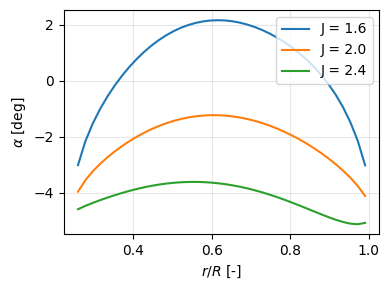

In [5]:
#Angle of attack
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('alpha', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_alpha.pdf"))


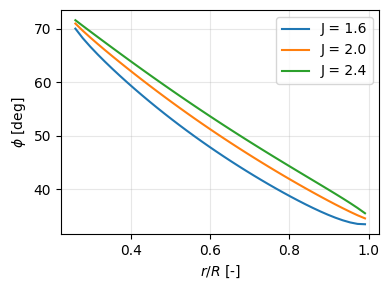

In [6]:
#Inflow anlge
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('phi', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_phi.pdf"))

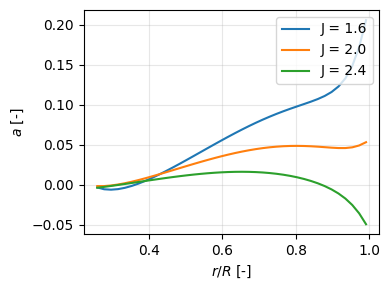

In [20]:
#Axial induction factor 
#Inflow anlge
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('a', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_axial_induction.pdf"))

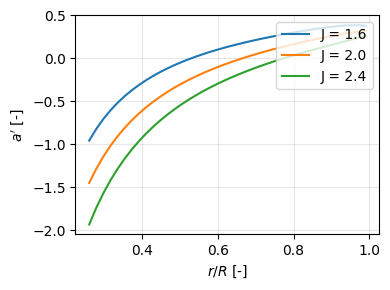

In [21]:
#Azimuthal induction factor 
#Axial induction factor 
#Inflow anlge
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('aline', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_tang_induction.pdf"))

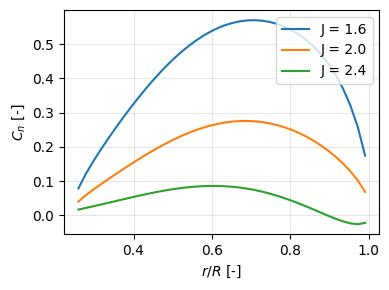

In [9]:
#Axial loading Cx
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('Cx', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Cx.pdf"))

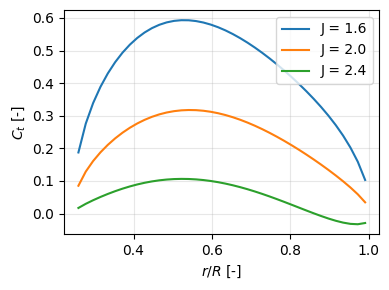

In [10]:
#Azimuthal loading Cy
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('Cy', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Cy.pdf"))

[np.float64(0.07837274975348932), np.float64(0.030404588961665605), np.float64(0.0058656370515569115)]
[1.6, 2, 2.4]


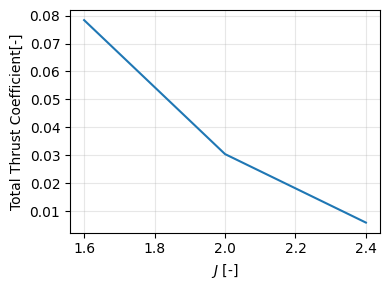

In [32]:
#Total thrust coeficient #TODO need to implement in the code first
print(TC_l)
print(J)
fig, ax = plt.subplots(figsize=(4,3))
if ax is None:
    fig, ax = plt.subplots(figsize=(5,4))    
    
ax.plot(J, TC_l)

ax.set_xlabel(r"$J$ [-]")
ax.set_ylabel(r"Total Thrust Coefficient[-]")
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(plot_dir.joinpath("total_thrust_coefficient_J.pdf"))

[np.float64(0.21983504898856543), np.float64(0.06822773808384713), np.float64(0.010968715636782908)]
[1.6, 2, 2.4]


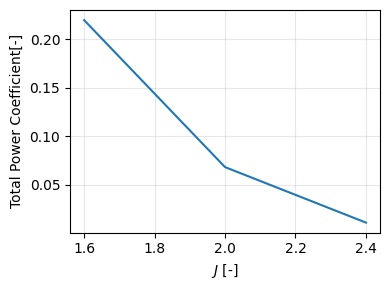

In [31]:
#Total Power coeficient t
print(PC_l)
print(J)
fig, ax = plt.subplots(figsize=(4,3))
if ax is None:
    fig, ax = plt.subplots(figsize=(5,4))    
    
ax.plot(J, PC_l)

ax.set_xlabel(r"$J$ [-]")
ax.set_ylabel(r"Total Power Coefficient[-]")
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(plot_dir.joinpath("total_power_coefficient_J.pdf"))

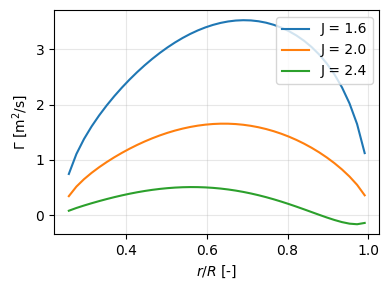

In [13]:
#Distribution of the circulation(Gamma) along the blade span 
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('gamma', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Gamma.pdf"))

### LLM and BEM Comparison ###

In [14]:

model = ["LLM", "BEM"]
comp_df = []
comp_df.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_2.0.csv'), sep=r",")) 
comp_df.append(pd.read_csv(res_dir.joinpath('BEM_span_dist_J_2.0.csv'), sep=r",")) 

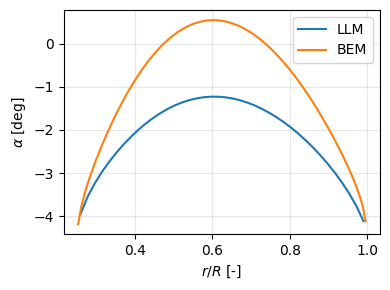

In [15]:
#Angle of attack
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('alpha', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_alpha.pdf"))


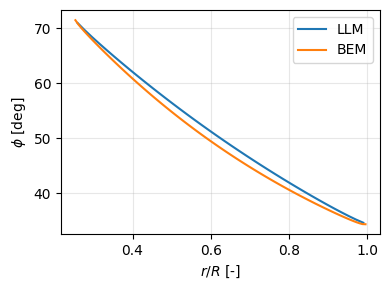

In [16]:
#PHI of attack
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('phi', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_Phi.pdf"))

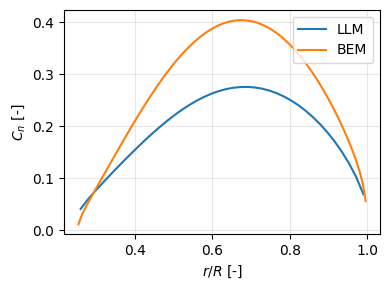

In [17]:
#Axial loading coefficient
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('Cx', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_Cx.pdf"))

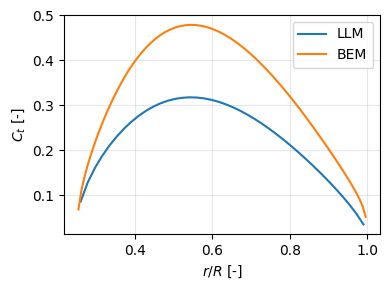

In [18]:
#Tangential loading coefficient
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('Cy', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_Cy.pdf"))

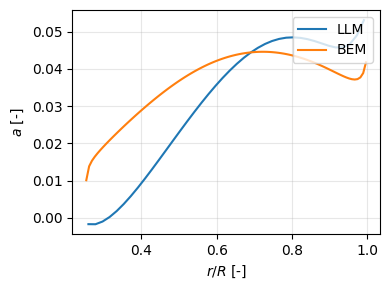

In [33]:
#Tangential loading coefficient
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('a', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_a.pdf"))

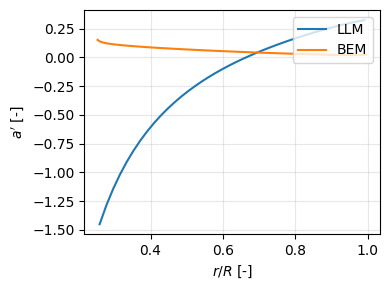

In [34]:
#Tangential loading coefficient
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('aline', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_aline.pdf"))